## Explore toy data generation


In [18]:
## Setup function for deterministic seed

def setup_seed(seed: int) -> None:
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

setup_seed(42)

In [19]:
import numpy as np
from numpy.typing import NDArray
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt

FloatArray = NDArray[np.float64]


def generate_toy_data(
    num_samples: int,
    feature_dim: int = 256,
    num_ground_truth_features: int = 512,
    num_active_features: float = 5.0,
    decay_rate: float = 0.99,
    random_seed: int | None = None,
) -> tuple[FloatArray, FloatArray, FloatArray, FloatArray]:
    """
    Generate toy data for sparse feature-learning experiments.

    Generation steps:
    1. Sample `num_ground_truth_features` random directions in R^{feature_dim}
       and normalize each one to unit norm.
    2. Build a random positive-semidefinite covariance matrix across latent
       features.
    3. Sample correlated Gaussian latents for each synthetic sample.
    4. Map those Gaussian latents through the standard normal CDF to get
       correlated values in (0, 1).
    5. Apply index-based decay so lower-index features are generally more
       common.
    6. Rescale probabilities so the expected number of active features is
       `num_active_features`.
    7. Draw Bernoulli support masks and assign Uniform(0, 1) amplitudes to
       active features.
    8. Form each observed sample as a linear combination of normalized ground-
       truth feature directions.

    Returns
    -------
    dataset : NDArray[np.float64], shape (num_samples, feature_dim)
    ground_truth_features : NDArray[np.float64], shape (feature_dim, num_ground_truth_features)
    sparse_coefficients : NDArray[np.float64], shape (num_samples, num_ground_truth_features)
    final_probabilities : NDArray[np.float64], shape (num_samples, num_ground_truth_features)
    """

    # Use assert statements for basic input validation, with informative error messages.
    assert num_samples > 0, f"num_samples must be positive, got {num_samples}."
    assert feature_dim > 0, f"feature_dim must be positive, got {feature_dim}."
    assert (
        num_ground_truth_features > 0
    ), f"num_ground_truth_features must be positive, got {num_ground_truth_features}."
    assert (
        num_active_features >= 0
    ), f"num_active_features must be nonnegative, got {num_active_features}."
    assert decay_rate > 0, f"decay_rate must be positive, got {decay_rate}."

    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------------------------
    # 1) Sample ground-truth feature directions, then normalize columns.
    #    Shape: (feature_dim, num_ground_truth_features)
    # ------------------------------------------------------------------
    ground_truth_features: FloatArray = rng.standard_normal(
        size=(feature_dim, num_ground_truth_features)
    )
    column_norms: FloatArray = np.linalg.norm(ground_truth_features, axis=0)
    column_norms = np.where(column_norms == 0.0, 1.0, column_norms)
    ground_truth_features = ground_truth_features / column_norms

    # ------------------------------------------------------------------
    # 2) Build a random covariance matrix for correlated latent features.
    # ------------------------------------------------------------------
    covariance_seed: FloatArray = rng.standard_normal(
        size=(num_ground_truth_features, num_ground_truth_features)
    )
    covariance: FloatArray = covariance_seed @ covariance_seed.T

    eigenvalues: FloatArray = np.linalg.eigvalsh(covariance)
    min_eigenvalue = float(np.min(eigenvalues))
    max_eigenvalue = float(np.max(eigenvalues))
    print(
        "The min and max eigenvalue of the covariance matrix are "
        f"{min_eigenvalue:.4f} and {max_eigenvalue:.4f}."
    )
    plt.hist(eigenvalues, bins=100)
    plt.title("Eigenvalues of covariance matrix")
    plt.figure()
    plt.hist(covariance.flatten(), bins=100)
    plt.title("Entries of covariance matrix")

    # ------------------------------------------------------------------
    # 3) Draw correlated Gaussian latents for all samples at once.
    # ------------------------------------------------------------------
    mean: FloatArray = np.zeros(num_ground_truth_features, dtype=np.float64)
    gaussian_samples: FloatArray = rng.multivariate_normal(
        mean,
        covariance,
        size=num_samples,
    )

    # ------------------------------------------------------------------
    # 4) Map Gaussian samples through the standard normal CDF.
    # ------------------------------------------------------------------
    correlated_feature_probs: FloatArray = norm.cdf(gaussian_samples)

    # ------------------------------------------------------------------
    # 5) Allocate outputs and precompute feature indices for decay.
    # ------------------------------------------------------------------
    sparse_coefficients: FloatArray = np.zeros(
        (num_samples, num_ground_truth_features), dtype=np.float64
    )
    dataset: FloatArray = np.zeros((num_samples, feature_dim), dtype=np.float64)
    final_probabilities: FloatArray = np.zeros(
        (num_samples, num_ground_truth_features), dtype=np.float64
    )
    feature_indices: FloatArray = np.arange(num_ground_truth_features, dtype=np.float64)

    # ------------------------------------------------------------------
    # 6) Per sample, apply decay and rescale probabilities to match the
    #    desired expected active-feature count.
    # 7) Sample Bernoulli support and Uniform(0,1) amplitudes.
    # 8) Form observed vector by linear combination of latent features.
    # ------------------------------------------------------------------
    for i in tqdm(range(num_samples)):
        decayed_feature_probs: FloatArray = np.power(
            correlated_feature_probs[i],
            feature_indices * decay_rate,
        )

        mean_prob = float(np.mean(decayed_feature_probs))
        if mean_prob <= 0.0:
            raise ValueError(
                "Mean decayed probability became non-positive, which should "
                "not happen with valid inputs."
            )

        rescaled_probs: FloatArray = decayed_feature_probs / mean_prob
        rescaled_probs = (
            num_active_features * rescaled_probs / num_ground_truth_features
        )

        final_probabilities[i] = rescaled_probs

        binary_vector: FloatArray = rng.binomial(1, rescaled_probs).astype(np.float64)
        activations: FloatArray = binary_vector * rng.uniform(
            0.0,
            1.0,
            num_ground_truth_features,
        )

        sparse_coefficients[i] = activations
        dataset[i] = ground_truth_features @ activations

    return dataset, ground_truth_features, sparse_coefficients, final_probabilities

### `generate_toy_data` generation steps

1. Sample Gaussian ground-truth feature vectors and normalize each column to unit norm.
2. Build a random positive-semidefinite covariance matrix over latent features.
3. Draw correlated Gaussian latent samples for each example.
4. Convert Gaussian samples to correlated probabilities using the standard normal CDF.
5. Apply feature-index decay so lower-index features activate more often.
6. Rescale probabilities so the expected active-feature count per sample is `num_active_features`.
7. Sample Bernoulli supports, then assign Uniform(0, 1) magnitudes to active features.
8. Generate each observed sample as a linear combination of ground-truth features.


#### Metrics for checking quality of toy data

In [20]:
from __future__ import annotations

from typing import Dict

import numpy as np
from numpy.typing import NDArray


FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]


def binary_support(sparse_coefficients: FloatArray) -> IntArray:
    """Return binary support mask."""
    return (sparse_coefficients > 0).astype(np.int64)


def mean_active_features_per_sample(sparse_coefficients: FloatArray) -> float:
    """Return mean number of active features per sample."""
    support = binary_support(sparse_coefficients)
    active_counts = support.sum(axis=1)
    return float(active_counts.mean())


def activation_frequency_vs_feature_index(sparse_coefficients: FloatArray) -> FloatArray:
    """Return activation frequency for each feature index."""
    support = binary_support(sparse_coefficients).astype(np.float64)
    return support.mean(axis=0)


def invalid_probability_rate(probabilities: FloatArray) -> float:
    """Return fraction of probabilities outside [0, 1]."""
    invalid = (probabilities < 0.0) | (probabilities > 1.0)
    return float(invalid.mean())


def count_negative_entries(dataset: FloatArray) -> int:
    """Return the number of strictly negative entries in the dataset."""

    return int(np.sum(dataset < 0.0))

def mean_abs_offdiag_correlation_binary_activations(
    sparse_coefficients: FloatArray,
) -> float:
    """Return mean absolute off-diagonal correlation of binary activations."""
    support = binary_support(sparse_coefficients).astype(np.float64)
    corr = np.corrcoef(support, rowvar=False)

    if corr.ndim != 2 or corr.shape[0] != corr.shape[1]:
        raise ValueError("Correlation matrix must be square.")

    mask = ~np.eye(corr.shape[0], dtype=bool)
    offdiag = corr[mask]
    offdiag = offdiag[np.isfinite(offdiag)]

    if offdiag.size == 0:
        return float("nan")

    return float(np.abs(offdiag).mean())


def compute_core_toy_data_metrics(
    sparse_coefficients: FloatArray,
    probabilities: FloatArray,
) -> Dict[str, object]:
    """Return the 4 core toy-data metrics."""
    return {
        "mean_active_features_per_sample": mean_active_features_per_sample(
            sparse_coefficients
        ),
        "activation_frequency_vs_feature_index": activation_frequency_vs_feature_index(
            sparse_coefficients
        ),
        "invalid_probability_rate": invalid_probability_rate(probabilities),
        "mean_abs_offdiag_correlation_binary_activations": (
            mean_abs_offdiag_correlation_binary_activations(sparse_coefficients)
        ),
    }


#### Instantiate the required arguments

In [21]:
num_samples = 100000
feature_dim = 256
num_ground_truth_features = 512
num_active_features = 5

The min and max eigenvalue of the covariance matrix are 0.0032 and 2041.8699.


100%|██████████| 100000/100000 [00:03<00:00, 26230.50it/s]


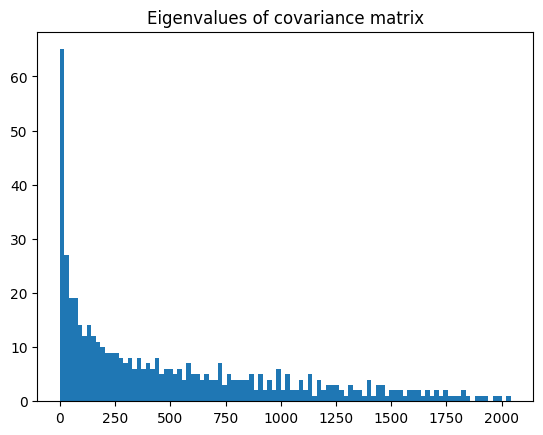

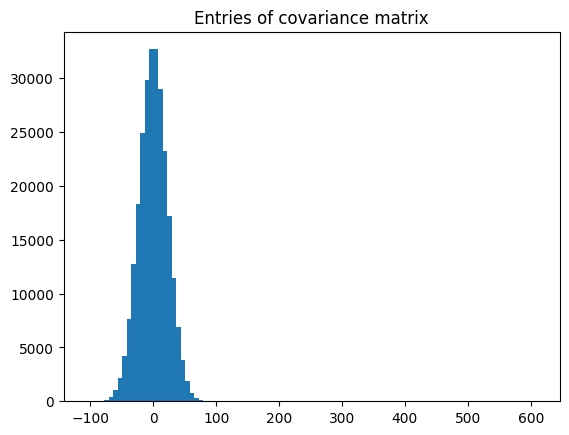

In [22]:
dataset, ground_truth_features, sparse_coefficients, final_probabilities = generate_toy_data(
    num_samples=num_samples,
    feature_dim=feature_dim,
    num_ground_truth_features=num_ground_truth_features,
    num_active_features=num_active_features,
)



In [17]:
metrics = compute_core_toy_data_metrics(
    sparse_coefficients=sparse_coefficients,
    probabilities=final_probabilities,
)

print(metrics["mean_active_features_per_sample"])
print(metrics["activation_frequency_vs_feature_index"].shape)
print(metrics["invalid_probability_rate"])
print(metrics["mean_abs_offdiag_correlation_binary_activations"])

4.98985
(512,)
0.0
0.002538138987129174


In [23]:
num_negative_entries = count_negative_entries(dataset)
print(f"Number of negative entries in dataset: {num_negative_entries}")

Number of negative entries in dataset: 12670437


In [24]:
# Show to 10 most negative entries in dataset
num_to_show = 10
flat_dataset = dataset.flatten()
sorted_indices = np.argsort(flat_dataset)
most_negative_indices = sorted_indices[:num_to_show]
print("Most negative entries in dataset:")
for idx in most_negative_indices:
    value = flat_dataset[idx]
    print(f"Index {idx}: {value:.6f}")

Most negative entries in dataset:
Index 1344315: -0.652680
Index 9248980: -0.583916
Index 12514961: -0.580667
Index 21756006: -0.577915
Index 14805136: -0.568120
Index 19188735: -0.563828
Index 19873332: -0.557409
Index 592749: -0.549232
Index 20203007: -0.548578
Index 24828451: -0.548484


In [28]:
def percentage_zero_entries(tensor: np.ndarray) -> float:
    """
    Percentage of exactly-zero entries in an N-dimensional tensor.
    """
    return 100.0 * np.mean(tensor == 0)

zero_entries_in_ground_truth_features = percentage_zero_entries(ground_truth_features)
zero_entries_in_ground_truth_features

np.float64(0.0)

In [ ]:
perce